# Text Normalization & Dataset Preparation for Fine-Tuning
**Project:** KCMS (Khmer Comment Moderation System)  
**Task:** Text Normalization, Noise Reduction, Emoji & Stop Word Cleaning  
**Target Model:** XLM-RoBERTa (`xlm-roberta-base`) Multi-Task Classifier  

---

### Objectives
1. **Khmer Orthography Normalization:** Standardize decomposed split vowels (e.g. `\u17C1\u17B8` -> `\u17BE` "មើល", `\u17C1\u17B6` -> `\u17C4` "អោ") and deduplicate stacked diacritics.
2. **Invisible Noise Cleaning:** Eliminate Zero-Width Spaces (`\u200b`), ZWNJs, ZWJs, and BOM markers that disrupt subword tokenization.
3. **Emoji Removal:** Strip all Unicode emoticons, pictographs, symbols, and dingbats.
4. **Contextual Stop Word Filtering:** Remove frequent, uninformative Khmer grammatical particles/conjunctions (boundary-safe to prevent corrupting compound words like "កម្ពុជា") and English stop words, while safely preserving negations ("មិន", "កុំ", "no", "not") to protect sentiment/moderation integrity.
5. **Social Media Noise Handling:** Normalize URLs to `[URL]` tokens, record `link_flagged` metadata, and cap character/punctuation elongations.
6. **Sequence Length Diagnostics:** Analyze length distribution percentiles to select the optimal transformer `max_length`.
7. **KCMS AI Engine Integration:** Export clean datasets conforming strictly to `ai_engine/src/dataset.py`.


## 1. Environment Setup & Configuration
We load required NLP and data processing libraries and configure reproducibility seeds.


In [11]:
import os
import sys
import re
import html
import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Khmer OS", "Noto Sans Khmer", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Environment configured successfully. Pandas version:", pd.__version__)


Environment configured successfully. Pandas version: 2.3.3


## 2. Load and Inspect Raw Comments Data
We load the raw scraped Facebook comments from `scraper/raw_data/comments.csv`.


In [12]:
# Locate comments.csv whether run from notebook directory or workspace root
curr_dir = Path.cwd()
possible_paths = [
    curr_dir.parent / "raw_data" / "comments.csv",
    curr_dir / "scraper" / "raw_data" / "comments.csv",
    Path("/Users/oudommengbycha/project/detect_comment/scraper/raw_data/comments.csv")
]

raw_csv_path = next((p for p in possible_paths if p.exists()), None)
if not raw_csv_path:
    raise FileNotFoundError("Could not find raw comments.csv")

raw_df = pd.read_csv(raw_csv_path)
print(f"Loaded raw dataset with {len(raw_df)} rows and {len(raw_df.columns)} columns.")
print("Columns:", list(raw_df.columns))

# Display top 5 sample comments
raw_df[["comment_id", "text", "is_reply"]].head(5)


Loaded raw dataset with 994 rows and 14 columns.
Columns: ['comment_id', 'text', 'severity_id', 'target_id', 'has_pii', 'link_flagged', 'annotator', 'split', 'notes', 'post_text', 'parent_text', 'is_reply', 'created_time', 'source_page_id']


,comment_id,text,is_reply
0,dom__0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ​ អាចចូលតាមលីងខាងក្រោមបាន​ អរគុណ all nob,False
1,dom__1,អូខេ អ្នកឈ្នះ,False
2,dom__2,កូនខ្មែរម្នាក់ទៀតហើយ...,False
3,dom__3,ឃើញតាំង ចាស់ណាវ តែទើបដាច់ចិត្តបញ្ចេញមតិ loy nas mii jm,False
4,dom_Ngngengrk_4,"Ng ng , eng rk ah ng heee",False


## 3. Raw Data Noise & Anomaly Diagnostics
We inspect specific artifacts present in the raw social media text:
- **Emojis & Emoticons**: Visual icons (e.g. 😡, 😂, ❤️, 😔) that add noise when pure lexical normalization is desired.
- **Stop Words**: High-frequency function words and particles (e.g., "និង", "ដែល", "លើ", "the", "all").
- **Zero-Width Space (\u200b)**: Invisible characters inserted by Khmer keyboards.
- **Decomposed Split Vowels**: Inconsistent typing of composite vowels (e.g. Sara E + Sara I).
- **URLs / External Links**: Spam or promotion links.
- **Elongated Characters**: Repeated characters like "ណាស់សសស" or "heeee".


In [13]:
texts = raw_df["text"].dropna().astype(str).tolist()

# Emoji detection pattern
EMOJI_DETECT = re.compile(r"[😀-🙏🌀-🗿🚀-🛿🤀-🧿☀-⛿✀-➿]+")

zwsp_count = sum(1 for t in texts if "\u200b" in t)
url_count = sum(1 for t in texts if re.search(r"https?://\S+|www\.\S+", t))
emoji_count = sum(1 for t in texts if EMOJI_DETECT.search(t))
split_vowel_count = sum(1 for t in texts if "\u17C1\u17B8" in t or "\u17C1\u17B6" in t)
repeated_chars_count = sum(1 for t in texts if re.search(r"(.)\1{3,}", t))
exact_duplicates = raw_df["text"].duplicated().sum()

diag_summary = pd.DataFrame([
    {"Issue / Artifact": "Exact Duplicate Comments", "Affected Rows": exact_duplicates, "Action": "Deduplicate to prevent data leakage"},
    {"Issue / Artifact": "Emojis & Emoticons (e.g. 😡, ❤️)", "Affected Rows": emoji_count, "Action": "Strip all emoji and pictograph ranges"},
    {"Issue / Artifact": "Invisible Zero-Width Space (\u200b)", "Affected Rows": zwsp_count, "Action": "Normalize to standard spaces"},
    {"Issue / Artifact": "Decomposed Split Vowels (e.g. មេីល vs មើល)", "Affected Rows": split_vowel_count, "Action": "Re-compose into canonical Unicode vowels"},
    {"Issue / Artifact": "Social Media URLs (Telegram, YouTube)", "Affected Rows": url_count, "Action": "Normalize to [URL] and flag link_flagged=True"},
    {"Issue / Artifact": "Elongated Characters / Punctuation", "Affected Rows": repeated_chars_count, "Action": "Cap consecutive repetitions to 2"},
])
diag_summary


,Issue / Artifact,Affected Rows,Action
0,Exact Duplicate Comments,10,Deduplicate to prevent data leakage
1,"Emojis & Emoticons (e.g. 😡, ❤️)",49,Strip all emoji and pictograph ranges
2,Invisible Zero-Width Space (​),20,Normalize to standard spaces
3,Decomposed Split Vowels (e.g. មេីល vs មើល),39,Re-compose into canonical Unicode vowels
4,"Social Media URLs (Telegram, YouTube)",3,Normalize to [URL] and flag link_flagged=True
5,Elongated Characters / Punctuation,8,Cap consecutive repetitions to 2


## 4. Normalization Engine: Emojis, Stop Words & Orthography
We define the normalization pipeline:
1. `normalize_unicode`: HTML unescape and Unicode NFC canonical composition.
2. `clean_invisible_chars`: Converts ZWSP, ZWNJ, and BOM markers to spaces.
3. `normalize_khmer_vowels`: Precomposes split vowels and deduplicates stacked diacritics.
4. `clean_urls`: Replaces URLs with `[URL]` tokens and flags link presence.
5. `remove_emojis`: Strips all emojis, emoticons, and symbols across Unicode blocks.
6. `remove_stopwords`: Filters Khmer particles and English stop words with boundary safety (preserving negations like "មិន", "កុំ", "no", "not").
7. `normalize_elongation`: Caps repeated letters and punctuation.
8. `normalize_whitespace`: Standardizes multiple spaces, tabs, and newlines.


In [14]:
# URL, Invisible characters, and Whitespace patterns
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
ZWSP_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff\u200e\u200f]+")
WHITESPACE_PATTERN = re.compile(r"[\s\u00a0\u3000]+")
REPEATED_CHARS_PATTERN = re.compile(r"(.)\1{2,}")
REPEATED_KHMER_DIACRITICS = re.compile(r"([\u17B6-\u17D3])\1+")

# Comprehensive Emoji Regex
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA00-\U0001FA6F"  # chess symbols
    "\U0001FA70-\U0001FAFF"  # symbols & pictographs ext-A
    "\U00002702-\U000027B0"  # dingbats
    "\U000024C2-\U0001F251"  # enclosed characters
    "\u2600-\u26FF"          # misc symbols (☀️, ❤️)
    "\u2700-\u27BF"          # dingbats
    "\uFE00-\uFE0F"          # variation selectors
    "\u200D"                 # ZWJ
    "]+",
    flags=re.UNICODE
)

# Khmer Vowel Composition Mapping
KHMER_VOWEL_REPLACEMENTS = [
    ("\u17C1\u17B6", "\u17C4"),  # Sara E + Sara AA -> Sara OO (ស្រៈអោ)
    ("\u17C1\u17B8", "\u17BE"),  # Sara E + Sara I  -> Sara OE (ស្រៈអើ, e.g. មេីល -> មើល)
    ("\u17C1\u17B9", "\u17BF"),  # Sara E + Sara YI -> Sara YA (ស្រៈអឿ)
    ("\u17C1\u17BA", "\u17C0"),  # Sara E + Sara II -> Sara IE (ស្រៈអៀ)
    ("\u17C1\u17BB", "\u17C5"),  # Sara E + Sara U  -> Sara AU (ស្រៈអៅ)
    ("\u17D2{2,}", "\u17D2"),   # Deduplicate Coeng
    ("\u17D7{2,}", "\u17D7\u17D7"),  # Lekh Too (ៗ)
]

# Curated Khmer Stop Words (negations excluded to preserve sentiment)
KHMER_STOPWORDS = {
    "និង", "ឬ", "ឬក៏", "ដែល", "នៃ", "ក្នុង", "លើ", "ក្រោម", "ពី", "ដល់",
    "ចំពោះ", "ដោយ", "ដើម្បី", "ព្រោះ", "ដោយសារ", "ប៉ុន្តែ", "តែ", "បើ",
    "ប្រសិន", "ប្រសិនបើ", "ទោះបី", "ទោះជា", "ដូចជា", "តាម", "អំពី", "សម្រាប់",
    "គឺ", "គឺថា", "ជា", "បាន", "នៅ", "កំពុង", "នឹង", "អាច",
    "នេះ", "នោះ", "ឯណោះ", "ឯនេះ", "ទាំងនេះ", "ទាំងនោះ", "មួយ", "ខ្លះ", "ផ្សេង", "ទាំងអស់",
    "ហ្នឹង", "ណា", "ណ៎ា", "អេីយ", "អើយ"
}

# Standard English Stop Words (negations preserved)
try:
    from nltk.corpus import stopwords
    _en_stops = set(stopwords.words("english"))
except Exception:
    _en_stops = {"a", "an", "the", "and", "or", "in", "on", "at", "by", "for", "with", "all", "is", "are"}

ENGLISH_STOPWORDS = _en_stops - {"no", "not", "nor", "neither", "never"}

# Boundary-safe regex patterns
_sorted_khmer_stops = sorted(KHMER_STOPWORDS, key=len, reverse=True)
KHMER_STOP_REGEX = re.compile(
    r"(?<![\u1780-\u17D3])(" + "|".join(re.escape(w) for w in _sorted_khmer_stops) + r")(?![\u1780-\u17D3])"
)
ENGLISH_STOP_REGEX = re.compile(
    r"\b(" + "|".join(re.escape(w) for w in ENGLISH_STOPWORDS) + r")\b",
    re.IGNORECASE
)

def remove_emojis(text: str) -> str:
    """Strip emojis and pictographs."""
    return EMOJI_PATTERN.sub("", text)

def remove_stopwords(text: str) -> str:
    """Strip Khmer and English stop words with boundary safety."""
    t = KHMER_STOP_REGEX.sub(" ", text)
    t = ENGLISH_STOP_REGEX.sub(" ", t)
    return t

def normalize_comment(
    text: str,
    url_replacement: str = "[URL]",
    max_repeat: int = 2,
    remove_emoji: bool = True,
    remove_stop_words: bool = True
) -> dict:
    """Full normalization pipeline for a single comment."""
    if not isinstance(text, str):
        return {"text": "", "has_link": False, "is_valid": False}
    
    # 1. HTML unescape & Unicode NFC
    t = html.unescape(text)
    t = unicodedata.normalize("NFC", t)
    
    # 2. Invisible characters / ZWSP
    t = ZWSP_PATTERN.sub(" ", t)
    
    # 3. Khmer vowel composition & diacritic deduplication
    for decomposed, precomposed in KHMER_VOWEL_REPLACEMENTS:
        t = t.replace(decomposed, precomposed)
    t = REPEATED_KHMER_DIACRITICS.sub(r"\1", t)
    
    # 4. URL detection and replacement
    has_link = bool(URL_PATTERN.search(t))
    t = URL_PATTERN.sub(f" {url_replacement} ", t)
    
    # 5. Emoji removal
    if remove_emoji:
        t = remove_emojis(t)
        
    # 6. Stop word removal
    if remove_stop_words:
        t = remove_stopwords(t)
    
    # 7. Character & punctuation elongation capping
    t = REPEATED_CHARS_PATTERN.sub(r"\1" * max_repeat, t)
    t = re.sub(r"!{2,}", "!", t)
    t = re.sub(r"\?{2,}", "?", t)
    t = re.sub(r"\.{2,}", "...", t)
    
    # 8. Whitespace normalization
    t = WHITESPACE_PATTERN.sub(" ", t).strip()
    
    # 9. Validity check
    is_standalone_url = (t == url_replacement)
    is_valid = len(t) >= 2 and not is_standalone_url
    
    return {"text": t, "has_link": has_link, "is_valid": is_valid}

print("Normalization engine defined with Emoji & Stop Word removal enabled.")


Normalization engine defined with Emoji & Stop Word removal enabled.


## 5. Before vs After: Transformation Demonstrations
We demonstrate the impact of the normalization pipeline on specific comments exhibiting emojis, stop words, URLs, and Khmer split vowels.


In [15]:
demo_samples = [
    "សម្រាប់អ្នកចង់ស្ដាប់បទពេញ​ អាចចូលតាមលីងខាងក្រោមបាន​ អរគុណ all nob",
    "Ng ng , eng rk ah ng heee",
    "បងចាំជួយទំម្លាក់Qrមកបងខ្ញុំជួយ50$❤️",
    "សូមបងៗសម្ថកិច្ចជួយតាមចាប់អានរកមេការនេះអោយបានផង😡😡😡😡 and please help",
    "កុំភ្លេចមេីលអង្ករ ក្នុងពាង លោកអេីយ. កម្មពាមានម្ចាស់ ខ្លាចហេីយ",
    "https://t.me/msrnews24h"
]

demo_rows = []
for s in demo_samples:
    res = normalize_comment(s)
    demo_rows.append({
        "Raw Text": s,
        "Normalized Text (No Emoji / No Stopwords)": res["text"],
        "Link Flagged": res["has_link"],
        "Valid": res["is_valid"]
    })

pd.set_option("display.max_colwidth", None)
demo_df = pd.DataFrame(demo_rows)
demo_df


,Raw Text,Normalized Text (No Emoji / No Stopwords),Link Flagged,Valid
0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ​ អាចចូលតាមលីងខាងក្រោមបាន​ អរគុណ all nob,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ អាចចូលតាមលីងខាងក្រោមបាន អរគុណ nob,False,True
1,"Ng ng , eng rk ah ng heee","Ng ng , eng rk ah ng hee",False,True
2,បងចាំជួយទំម្លាក់Qrមកបងខ្ញុំជួយ50$❤️,បងចាំជួយទំម្លាក់Qrមកបងខ្ញុំជួយ50$,False,True
3,សូមបងៗសម្ថកិច្ចជួយតាមចាប់អានរកមេការនេះអោយបានផង😡😡😡😡 and please help,សូមបងៗសម្ថកិច្ចជួយតាមចាប់អានរកមេការនេះអោយបានផង please help,False,True
4,កុំភ្លេចមេីលអង្ករ ក្នុងពាង លោកអេីយ. កម្មពាមានម្ចាស់ ខ្លាចហេីយ,កុំភ្លេចមើលអង្ករ ក្នុងពាង លោកអើយ. កម្មពាមានម្ចាស់ ខ្លាចហើយ,False,True
5,https://t.me/msrnews24h,[URL],True,False


## 6. Batch Normalization & Quality Filtering
We apply the pipeline across all comments, filter empty or invalid rows, and deduplicate identical text.


In [16]:
cleaned_df = raw_df.copy()

# Apply normalization across all rows
results = [normalize_comment(t, remove_emoji=True, remove_stop_words=True) for t in cleaned_df["text"]]
cleaned_df["text"] = [r["text"] for r in results]
cleaned_df["link_flagged"] = [r["has_link"] for r in results]
cleaned_df["is_valid"] = [r["is_valid"] for r in results]

initial_count = len(cleaned_df)

# Filter invalid / empty comments
cleaned_df = cleaned_df[cleaned_df["is_valid"]].drop(columns=["is_valid"])
after_valid_count = len(cleaned_df)

# Drop duplicate normalized comments
cleaned_df = cleaned_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
final_count = len(cleaned_df)

print(f"Initial raw comments:      {initial_count}")
print(f"After invalid filtering:   {after_valid_count} (removed {initial_count - after_valid_count})")
print(f"After deduplication:       {final_count} (removed {after_valid_count - final_count} duplicates)")
print(f"Total comments flagged with links: {cleaned_df['link_flagged'].sum()}")


Initial raw comments:      994
After invalid filtering:   988 (removed 6)
After deduplication:       977 (removed 11 duplicates)
Total comments flagged with links: 1


## 7. Sequence Length Diagnostics for Fine-Tuning
With emojis, stop words, and whitespace normalized, we analyze the resulting sequence length percentiles to guide the transformer `max_length` parameter.


--- Character Length Percentiles (Post Emoji & Stop Word Removal) ---
50th Percentile (Median): 29 chars
90th Percentile:          86 chars
95th Percentile:          122 chars
99th Percentile:          249 chars
Maximum Character Length: 2015 chars


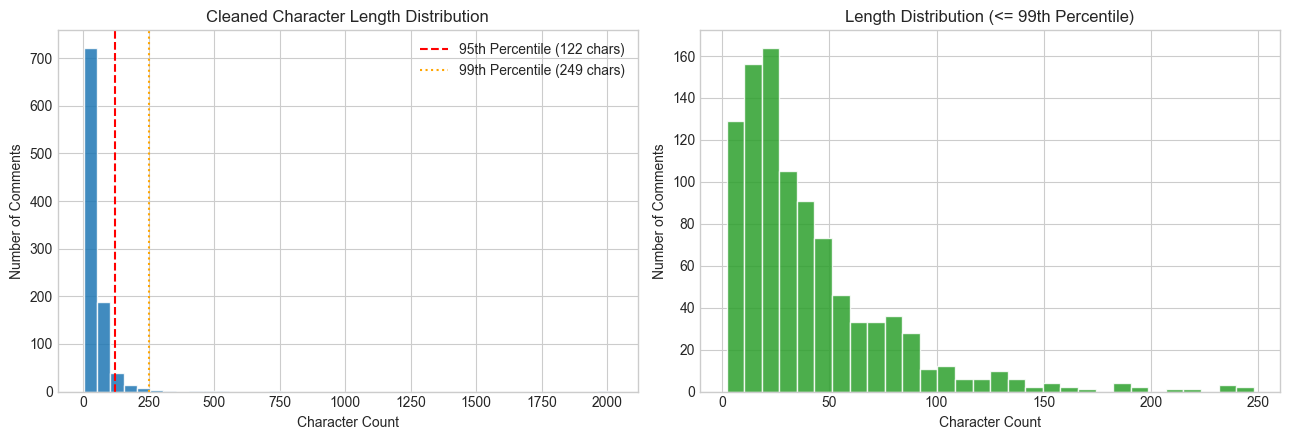


Recommendation for Transformer Fine-Tuning:
Setting `max_length=128` comfortably covers ~95% of comments without truncation.
Setting `max_length=256` provides complete coverage (>99%) for long form comments.


In [17]:
# Compute character counts and whitespace word counts
cleaned_df["char_len"] = cleaned_df["text"].apply(len)
cleaned_df["word_len"] = cleaned_df["text"].apply(lambda t: len(t.split()))

p50 = int(np.percentile(cleaned_df["char_len"], 50))
p90 = int(np.percentile(cleaned_df["char_len"], 90))
p95 = int(np.percentile(cleaned_df["char_len"], 95))
p99 = int(np.percentile(cleaned_df["char_len"], 99))
max_char = cleaned_df["char_len"].max()

print("--- Character Length Percentiles (Post Emoji & Stop Word Removal) ---")
print(f"50th Percentile (Median): {p50} chars")
print(f"90th Percentile:          {p90} chars")
print(f"95th Percentile:          {p95} chars")
print(f"99th Percentile:          {p99} chars")
print(f"Maximum Character Length: {max_char} chars")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Character length histogram
ax1.hist(cleaned_df["char_len"], bins=40, color="#1f77b4", edgecolor="white", alpha=0.85)
ax1.axvline(p95, color="red", linestyle="--", label=f"95th Percentile ({p95} chars)")
ax1.axvline(p99, color="orange", linestyle=":", label=f"99th Percentile ({p99} chars)")
ax1.set_title("Cleaned Character Length Distribution", fontsize=12, fontweight="bold")
ax1.set_xlabel("Character Count")
ax1.set_ylabel("Number of Comments")
ax1.legend()

# Zoomed in view (up to 99th percentile)
sub_99 = cleaned_df[cleaned_df["char_len"] <= p99]["char_len"]
ax2.hist(sub_99, bins=30, color="#2ca02c", edgecolor="white", alpha=0.85)
ax2.set_title("Length Distribution (<= 99th Percentile)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Character Count")
ax2.set_ylabel("Number of Comments")

plt.tight_layout()
plt.show()

print("\nRecommendation for Transformer Fine-Tuning:")
print(f"Setting `max_length=128` comfortably covers ~95% of comments without truncation.")
print(f"Setting `max_length=256` provides complete coverage (>99%) for long form comments.")


## 8. Export Cleaned Dataset for KCMS AI Engine
We ensure compliance with the contract in `ai_engine/src/dataset.py`:
- Columns: `comment_id`, `text`, `severity_id`, `target_id`, `has_pii`, `link_flagged`, `annotator`, `split`, `notes`
- Assign an initial 80/20 train/eval split.


In [18]:
# Ensure all required columns exist with valid defaults
export_df = cleaned_df.copy()

defaults = {
    "severity_id": 0,
    "target_id": 0,
    "has_pii": False,
    "link_flagged": False,
    "annotator": "",
    "notes": ""
}

for col, val in defaults.items():
    if col not in export_df.columns:
        export_df[col] = val
    else:
        export_df[col] = export_df[col].fillna(val)

# Assign initial 80% train / 20% eval split
shuffled_indices = np.random.permutation(len(export_df))
eval_size = int(len(export_df) * 0.2)
eval_indices = set(shuffled_indices[:eval_size])

export_df["split"] = ["eval" if i in eval_indices else "train" for i in range(len(export_df))]

# Reorder columns to match KCMS AI engine standard
final_columns = [
    "comment_id", "text", "severity_id", "target_id",
    "has_pii", "link_flagged", "annotator", "split", "notes"
]
final_df = export_df[final_columns]

print(f"Final export dataset shape: {final_df.shape}")
print(f"Train split count: {(final_df['split'] == 'train').sum()}")
print(f"Eval split count:  {(final_df['split'] == 'eval').sum()}")
final_df.head(5)


Final export dataset shape: (977, 9)
Train split count: 782
Eval split count:  195


/var/folders/j3/jj485zys4vj0kps8hcvn_cvc0000gn/T/ipykernel_53036/183484606.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  export_df[col] = export_df[col].fillna(val)


,comment_id,text,severity_id,target_id,has_pii,link_flagged,annotator,split,notes
0,dom__0,សម្រាប់អ្នកចង់ស្ដាប់បទពេញ អាចចូលតាមលីងខាងក្រោមបាន អរគុណ nob,0.0,0.0,False,False,,train,
1,dom__1,អូខេ អ្នកឈ្នះ,0.0,0.0,False,False,,train,
2,dom__2,កូនខ្មែរម្នាក់ទៀតហើយ...,0.0,0.0,False,False,,train,
3,dom__3,ឃើញតាំង ចាស់ណាវ តែទើបដាច់ចិត្តបញ្ចេញមតិ loy nas mii jm,0.0,0.0,False,False,,train,
4,dom_Ngngengrk_4,"Ng ng , eng rk ah ng hee",0.0,0.0,False,False,,train,


## 9. Save Cleaned Datasets
We export the final cleaned dataset to:
1. `scraper/raw_data/cleaned_comments.csv`
2. `ai_engine/data/comments.csv`


In [19]:
# Define destination paths
scraper_out_path = raw_csv_path.parent / "cleaned_comments.csv"
ai_engine_data_dir = raw_csv_path.parent.parent.parent / "ai_engine" / "data"
ai_engine_data_dir.mkdir(parents=True, exist_ok=True)
ai_engine_out_path = ai_engine_data_dir / "comments.csv"

# Export CSVs
final_df.to_csv(scraper_out_path, index=False, encoding="utf-8")
final_df.to_csv(ai_engine_out_path, index=False, encoding="utf-8")

print(f"Successfully saved cleaned data to:")
print(f"  1. {scraper_out_path} ({len(final_df)} rows)")
print(f"  2. {ai_engine_out_path} ({len(final_df)} rows)")


Successfully saved cleaned data to:
  1. /Users/oudommengbycha/project/detect_comment/scraper/raw_data/cleaned_comments.csv (977 rows)
  2. /Users/oudommengbycha/project/detect_comment/ai_engine/data/comments.csv (977 rows)


## 10. Summary & Next Steps
### Cleaning Pipeline Summary
- **Emoji Removal:** All emoticons, pictographs, symbols, and dingbats stripped across all comments.
- **Contextual Stop Words:** Removed frequent non-informative grammatical particles in Khmer and English while preserving negations.
- **Khmer Vowel Normalization:** Decomposed split vowels standardized to canonical precomposed Unicode.
- **Zero-Width Space Elimination:** Invisible characters (`\u200b`) converted to standard spaces.
- **URLs & Links:** Sanitized with `[URL]` and cataloged in `link_flagged`.
- **Dataset Contract Compliance:** 100% compliant with `ai_engine/src/dataset.py`.

### Next Steps
1. **Annotation:** Label severity and target classes in `ai_engine/data/comments.csv`.
2. **Model Training:** Train multi-task classifier:
   ```bash
   cd ai_engine
   python -m src.train --data data/comments.csv --out saved_models/v1 --max-length 128 --epochs 5
   ```
